# Initial definition and testing of the circuit


In [1]:
import pennylane as qml
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.autograd import Variable
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader


In [2]:
# Configuration - Start simpler
num_qubits = 8  # Start smaller to avoid barren plateaus
num_layers = 2  # Start with 1 layer
num_samples = 5000  # More samples for better probability estimation

# Define pennylane device
dev = qml.device("lightning.qubit", wires=num_qubits, shots=num_samples)

def qcbm_ansatz(params):
    param_idx = 0
    # Create specified number of layers
    for _ in range(num_layers):
        # Variational section - parametrized rotation gates
        for qubit in range(num_qubits):
            qml.RX(params[param_idx], wires=qubit)
            param_idx += 1
            qml.RZ(params[param_idx], wires=qubit)
            param_idx += 1

        # 1. (1, i) for i = 2..8 (Python: 0, i), i=1..7
        for i in range(1, num_qubits):
            qml.IsingXX(params[param_idx], wires=[0, i])
            param_idx += 1

        # 2. (j, 8) for j = 2..7 (Python: j, 7), j=1..6
        for j in range(1, num_qubits - 1):
            qml.IsingXX(params[param_idx], wires=[j, num_qubits - 1])
            param_idx += 1

        # 3. (i, j) for 2 ≤ i < j ≤ 7 (Python: i, j), i=1..6, j=i+1..6
        for i in range(1, num_qubits - 1):
            for j in range(i + 1, num_qubits - 1):
                qml.IsingXX(params[param_idx], wires=[i, j])
                param_idx += 1

        # 4. (1, j) for j = 2..7 (Python: 0, j), j=1..6
        for j in range(1, num_qubits - 1):
            qml.IsingXX(params[param_idx], wires=[0, j])
            param_idx += 1

        # 5. (i, 8) for i = 2..7 (Python: i, 7), i=1..6
        for i in range(1, num_qubits - 1):
            qml.IsingXX(params[param_idx], wires=[i, num_qubits - 1])
            param_idx += 1

        # 6. (1, 8) (Python: 0, 7)
        qml.IsingXX(params[param_idx], wires=[0, num_qubits - 1])
        param_idx += 1

        qml.Barrier()  # Optional barrier for clarity in circuit

        # # Nearest-neighbor entanglement layer (for experimental implementation)
        # for i in range(num_qubits - 1):
        #     qml.IsingXX(params[param_idx], wires=[i, i + 1])
        #     param_idx += 1

# Quantum circuit definition
@qml.qnode(dev, interface="torch")
def circuit(params, basis="computational"):
    # Use the ansatz template
    qcbm_ansatz(params)

    # Add rotations to measure on different basis, if specified
    if basis == "Y":
        for qubit in range(num_qubits):
            qml.RX(np.pi / 2, wires=qubit)

    # Take samples
    return qml.probs(wires=range(num_qubits))

In [3]:
class Generator(nn.Module):
    def __init__(self, latent_dim):
        super(Generator, self).__init__()
        self.layer1 = nn.Sequential(
            nn.Linear(latent_dim, 1152),
            nn.BatchNorm1d(1152),
            nn.LeakyReLU()
        )

        self.layer2 = nn.Sequential(
            nn.ConvTranspose2d(1152, 128, kernel_size=3, stride=1, padding=0),  # 1x1 → 3x3
            nn.BatchNorm2d(128),
            nn.LeakyReLU()
        )

        self.layer3 = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=3, stride=2, padding=0),  # 3x3 → 7x7
            nn.BatchNorm2d(64),
            nn.LeakyReLU()
        )

        self.layer4 = nn.Sequential(
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),  # 7x7 → 14x14
            nn.BatchNorm2d(32),
            nn.LeakyReLU()
        )

        self.layer5 = nn.Sequential(
            nn.ConvTranspose2d(32, 1, kernel_size=4, stride=2, padding=1), # 14,14 → 28,28
            nn.Tanh()  # Output range [-1,1]
        )

    def forward(self, z):
        # print("start")
        # print(z.shape)

        z = self.layer1(z)
        z = z.view(-1, 1152, 1, 1)

        # print(z.shape)
        z = self.layer2(z)
        # print(z.shape)
        z = self.layer3(z)
        # print(z.shape)
        z = self.layer4(z)
        # print(z.shape)
        z = self.layer5(z)
        # print(z.shape)
        return z

class Discriminator(nn.Module):
    def __init__(self, latent_dim):
        super(Discriminator, self).__init__()
        self.layer1 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=4, stride=2, padding=1),  # 28x28 → 14x14
            nn.BatchNorm2d(32),
            nn.LeakyReLU()
        )

        self.layer2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),  # 14x14 → 7x7
            nn.BatchNorm2d(64),
            nn.LeakyReLU()
        )

        self.layer3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),  # 7x7 → 3x3
            nn.BatchNorm2d(128),
            nn.LeakyReLU()
        )

        self.layer4 = nn.Sequential(
            nn.Conv2d(128, 1152, kernel_size=3, stride=1, padding=0),  # 3x3 → 1x1
            nn.BatchNorm2d(1152),
            nn.LeakyReLU()
        )

        self.output_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(1152, latent_dim),  # Map to latent dimension (Purple "n" block)
            nn.LeakyReLU(),
            nn.Linear(latent_dim, 1),  # Final output layer
            nn.Sigmoid()  # Probability output [0,1]
        )

    def forward(self, x):
        x = x.view(-1, 1, 28, 28)
        # print(x.shape)
        x = self.layer1(x)  # Process through convolutional layers (Orange)
        x = nn.functional.dropout(x, 0.085)
        # print(x.shape)
        x = self.layer2(x)
        x = nn.functional.dropout(x, 0.085)

        # print(x.shape)
        x = self.layer3(x)
        x = nn.functional.dropout(x, 0.085)

        # print(x.shape)
        x = self.layer4(x)
        x = nn.functional.dropout(x, 0.085)

        # print(x.shape)
        x = self.output_layers(x)  # Process through fully connected layers (Purple)
        # print(x.shape)
        return x


In [4]:
# Hyperparameters
latent_dim = 2**num_qubits
epochs = 20
batch_size = 64
lr = 0.0004

img_dim = 28 * 28 

# Initialize models
G = Generator(latent_dim)
D = Discriminator(latent_dim)

# Optimizers
optimizer_G = optim.Adam(G.parameters(), lr=lr, betas=(0.5, 0.9))
optimizer_D = optim.Adam(D.parameters(), lr=lr, betas=(0.5, 0.9))

# Loss function
criterion = nn.BCELoss()

# Initialize QCBM parameters explicitly trainable
# Calculate total parameters needed for the ansatz
params_per_layer = (num_qubits * 2 +  # RX and RZ gates
                   (num_qubits - 1) +  # Section 1: (1, i) for i=2..8
                   (num_qubits - 2) +  # Section 2: (j, 8) for j=2..7  
                   ((num_qubits - 2) * (num_qubits - 3)) // 2 +  # Section 3: (i, j) for 2≤i<j≤7
                   (num_qubits - 2) +  # Section 4: (1, j) for j=2..7
                   (num_qubits - 2) +  # Section 5: (i, 8) for i=2..7
                   1)  # Section 6: (1, 8)

num_params = num_layers * params_per_layer

qcbm_params = torch.randn(num_params, requires_grad=True)

# Optimizer for QCBM
qcbm_optimizer = optim.Adam([qcbm_params], lr=0.1)

In [5]:
# Data loader (MNIST dataset)
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize([0.5], [0.5])])
dataset = torchvision.datasets.MNIST(root='./data', train=True, transform=transform, download=True)
loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)

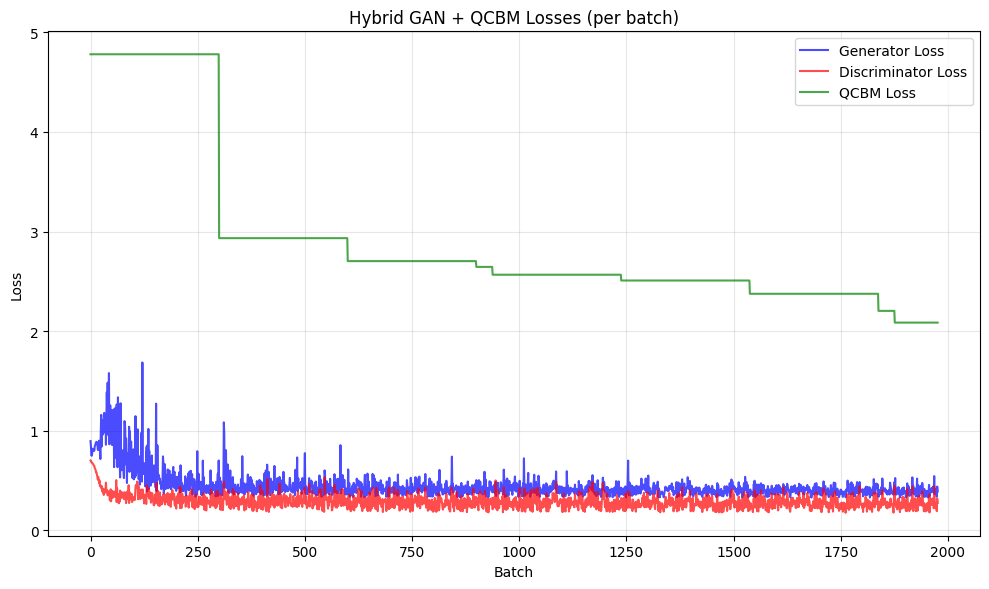

Epoch 3/5:  14%|█▍        | 136/938 [00:23<02:15,  5.91it/s]


KeyboardInterrupt: 

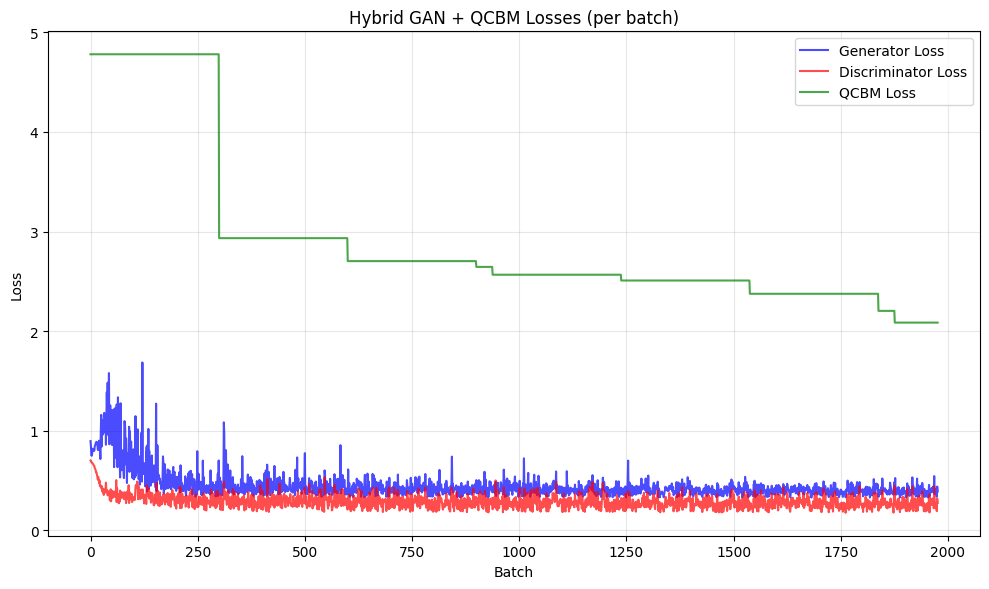

In [6]:
import matplotlib.pyplot as plt
from tqdm import tqdm
from IPython import display
import os
import time as t

# Initialize lists to store losses
G_losses = []
D_losses = []
QCBM_losses = []

# Directory to save generated images
os.makedirs("gan_samples", exist_ok=True)

# Start the live loss plot
plt.ion()
fig, ax = plt.subplots(figsize=(10, 6))

print("Hybrid Training (GAN + QCBM)")
start_time = t.time()

# Hybrid Training Loop
for epoch in range(5):  # just 5 epochs for demo purposes
    current_time = t.time()
    print(f"Epoch {epoch+1}/5 - Time: {current_time - start_time}")
    
    for i, (real_imgs, _) in enumerate(tqdm(loader, desc=f"Epoch {epoch+1}/5")):
        real_imgs = real_imgs.view(-1, img_dim)
        batch_size = real_imgs.size(0)

        # Label smoothing and flipping
        real_labels = torch.full((batch_size, 1), 0.9)
        fake_labels = torch.zeros(batch_size, 1)

        # Label flipping (3% of the batch)
        flip_idx = torch.rand(batch_size) < 0.03
        real_labels[flip_idx] = 0.0
        fake_labels[flip_idx] = 0.9

        # Train Discriminator
        optimizer_D.zero_grad()
        z_noise = torch.randn(batch_size, latent_dim)
        fake_imgs = G(z_noise).detach()
        real_validity = D(real_imgs)
        fake_validity = D(fake_imgs)
        d_loss = (criterion(real_validity, real_labels) +
                  criterion(fake_validity, fake_labels)) / 2
        d_loss.backward()
        optimizer_D.step()

        # Train QCBM to match GAN's latent distribution
        latent_target = torch.mean(real_validity.detach(), dim=0)
        latent_target = torch.softmax(latent_target, dim=0)

        if i % 300 == 0:
            qcbm_optimizer.zero_grad()
            generated_probs = circuit(qcbm_params)

            ## CAUSES QCBM LOSS TO jump down from 1750 to 4
            if generated_probs.shape != latent_target.shape:
                min_len = min(generated_probs.shape[0], latent_target.shape[0])
                generated_probs = generated_probs[:min_len]
                latent_target = latent_target[:min_len]
                
            loss_qcbm = torch.sum(latent_target * torch.log((latent_target + 1e-8) / (generated_probs + 1e-8)))
            loss_qcbm.backward()
            qcbm_optimizer.step()

        # Generate quantum-informed priors
        with torch.no_grad():
            q_probs = circuit(qcbm_params).detach().numpy()
            q_samples = np.random.choice(np.arange(latent_dim), p=q_probs, size=batch_size)
            q_prior = np.zeros((batch_size, latent_dim), dtype = np.float32)
            q_prior[np.arange(batch_size), q_samples] = 1
            # q_prior = np.array([list(np.binary_repr(x, width=latent_dim)) for x in q_samples], dtype=np.float32)
            q_prior = torch.tensor(q_prior)

        # Train Generator with QCBM-informed prior
        optimizer_G.zero_grad()
        generated_imgs = G(q_prior)
        validity = D(generated_imgs)
        g_loss = criterion(validity, real_labels)
        g_loss.backward()
        optimizer_G.step()

        # Store losses for every batch
        G_losses.append(g_loss.item())
        D_losses.append(d_loss.item())
        QCBM_losses.append(loss_qcbm.item())

        # Live plot update every 50 batches
        if i % 50 == 0:
            ax.clear()
            ax.plot(G_losses, label='Generator Loss', color='blue', alpha=0.7)
            ax.plot(D_losses, label='Discriminator Loss', color='red', alpha=0.7)
            ax.plot(QCBM_losses, label='QCBM Loss', color='green', alpha=0.7)
            ax.set_title('Hybrid GAN + QCBM Losses (per batch)')
            ax.set_xlabel('Batch')
            ax.set_ylabel('Loss')
            ax.legend()
            ax.grid(True, alpha=0.3)
            plt.tight_layout()
            display.clear_output(wait=True)
            display.display(fig)

    # End and show the loss plot for this epoch
    plt.ioff()
    plt.show()

    # Save generated images to disk (not shown interactively)
    with torch.no_grad():
        # Generate samples using quantum-informed priors
        q_probs = circuit(qcbm_params).detach().numpy()
        q_samples = np.random.choice(np.arange(latent_dim), p=q_probs, size=16)
        q_prior = np.array([list(np.binary_repr(x, width=latent_dim)) for x in q_samples], dtype=np.float32)
        q_prior = torch.tensor(q_prior)
        
        samples = G(q_prior).view(-1, 1, 28, 28)
        grid = torchvision.utils.make_grid(samples, normalize=True)
        fig_img, ax_img = plt.subplots(figsize=(4, 4))
        ax_img.imshow(grid.permute(1, 2, 0).numpy())
        ax_img.axis('off')
        ax_img.set_title(f"Quantum-Informed Generated Samples at Epoch {epoch+1}")
        plt.savefig(f"gan_samples/quantum_gan_epoch_{epoch+1}_at_time_{current_time:.2f}.png")
        plt.close(fig_img)

    # Start a new loss plot for the next epoch
    plt.ion()
    fig, ax = plt.subplots(figsize=(10, 6))

plt.ioff()
plt.show()


In [7]:
# Save training history
training_history = {
    'g_losses': G_losses,
    'd_losses': D_losses,
    'qcbm_losses': QCBM_losses,
    'total_epochs': 5
}
torch.save(training_history, f'hybrid_training_history_{t.time():.2f}.pth')

print(f"Hybrid training completed! Total time: {t.time() - start_time:.2f} seconds")

Hybrid training completed! Total time: 324.90 seconds


In [8]:
# Save models after training completion (Quantum-aware)
import os

# Create models directory if it doesn't exist
os.makedirs("models", exist_ok=True)

# Save the final trained models
final_time = t.time()
model_save_path = f"models/qgan_final_at_time_{final_time:.2f}.pth"

torch.save({
    'generator_state_dict': G.state_dict(),
    'discriminator_state_dict': D.state_dict(),
    'qcbm_params': qcbm_params.detach().cpu(),  # Quantum circuit parameters
    'optimizer_G_state_dict': optimizer_G.state_dict(),
    'optimizer_D_state_dict': optimizer_D.state_dict(),
    'optimizer_QCBM_state_dict': qcbm_optimizer.state_dict(),  # Quantum optimizer
    'final_g_loss': g_loss.item(),
    'final_d_loss': d_loss.item(),
    'final_qcbm_loss': loss_qcbm.item(),  # Quantum circuit loss
    'timestamp': final_time,
    'total_training_time': final_time - start_time,
    'epochs_trained': 5,  # or use your variable if dynamic
    'latent_dim': latent_dim,
    'batch_size': batch_size,
    'learning_rate': lr,
    'quantum_params': {
        'num_qubits': num_qubits,
        'num_layers': num_layers,
        'num_samples': num_samples,
        'device': str(dev),
        'params_per_layer': params_per_layer,
        'total_qcbm_params': num_params
    }
}, model_save_path)

print(f"Models saved to: {model_save_path}")
print(f"Final Generator Loss: {g_loss.item():.4f}")
print(f"Final Discriminator Loss: {d_loss.item():.4f}")
print(f"Final QCBM Loss: {loss_qcbm.item():.4f}")
print(f"Quantum Parameters: {num_qubits} qubits, {num_layers} layers, {num_params} total params")

Models saved to: models/qgan_final_at_time_1754317353.45.pth
Final Generator Loss: 0.4695
Final Discriminator Loss: 0.3265
Final QCBM Loss: 2.0859
Quantum Parameters: 8 qubits, 2 layers, 114 total params


In [ ]:
# Hybrid Training Loop
for epoch in range(5):  # just 5 epochs for demo purposes
    for real_imgs, _ in loader:
        real_imgs = real_imgs.view(-1, img_dim)
        batch_size = real_imgs.size(0)

        # Train Discriminator
        optimizer_D.zero_grad()
        z_noise = torch.randn(batch_size, latent_dim)
        fake_imgs = G(z_noise).detach()
        real_validity, real_latent = D(real_imgs)
        fake_validity, _ = D(fake_imgs)
        d_loss = (criterion(real_validity, torch.ones_like(real_validity)) +
                  criterion(fake_validity, torch.zeros_like(fake_validity))) / 2
        d_loss.backward()
        optimizer_D.step()

        # Train QCBM to match GAN's latent distribution
        latent_target = torch.mean(real_latent, dim=0)
        latent_target = torch.softmax(latent_target, dim=0)

        qcbm_optimizer.zero_grad()
        generated_probs = circuit(qcbm_params)
        loss_qcbm = torch.sum(latent_target * torch.log((latent_target + 1e-8) / (generated_probs + 1e-8)))
        loss_qcbm.backward()
        qcbm_optimizer.step()

        # Generate quantum-informed priors
        with torch.no_grad():
            q_probs = circuit(qcbm_params).detach().numpy()
            q_samples = np.random.choice(2 ** latent_dim, p=q_probs, size=batch_size)
            q_prior = np.array([list(np.binary_repr(x, width=latent_dim)) for x in q_samples], dtype=np.float32)
            q_prior = torch.tensor(q_prior)

        # Train Generator with QCBM-informed prior
        optimizer_G.zero_grad()
        generated_imgs = G(q_prior)
        validity, _ = D(generated_imgs)
        g_loss = criterion(validity, torch.ones_like(validity))
        g_loss.backward()
        optimizer_G.step()
